In [15]:
from keras.datasets import mnist
from sklearn import metrics
from sklearn.cluster import MiniBatchKMeans
import numpy as np


(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
x_train = x_train / 255.0
x_test = x_test / 255.0
X_train = x_train.reshape(len(x_train), -1)
X_test = x_test.reshape(len(x_test), -1)

total_clusters = len(np.unique(y_test))


def retrieve_info(cluster_labels, y_train):
    """
    Associates most probable class to each cluster
    :param cluster_labels:
    :param y_train:
    :return: dictionary of clusters assigned to each label
    """
    reference_labels = {}

    for i in range(len(np.unique(kmeans.labels_))):
        index = np.where(cluster_labels == i, 1, 0)
        num = np.bincount(y_train[index == 1]).argmax()
        reference_labels[i] = num

    return reference_labels


def calculate_metrics(model, output):
    print("Number of clusters: ", model.n_clusters)
    print("Inertia: ", model.inertia_)
    print("Accuracy: ", metrics.accuracy_score(number_labels, output))


kmeans = MiniBatchKMeans(n_clusters=256)
kmeans.fit(X_test)
reference_labels = retrieve_info(kmeans.labels_, y_test)
number_labels = np.random.rand(len(kmeans.labels_))
for i in range(len(kmeans.labels_)):
    number_labels[i] = reference_labels[kmeans.labels_[i]]
calculate_metrics(kmeans, y_test)

Number of clusters:  256
Inertia:  240097.75
Accuracy:  0.9036


In [16]:
centroids = kmeans.cluster_centers_
centroids.shape

(256, 784)

<Figure size 640x480 with 0 Axes>

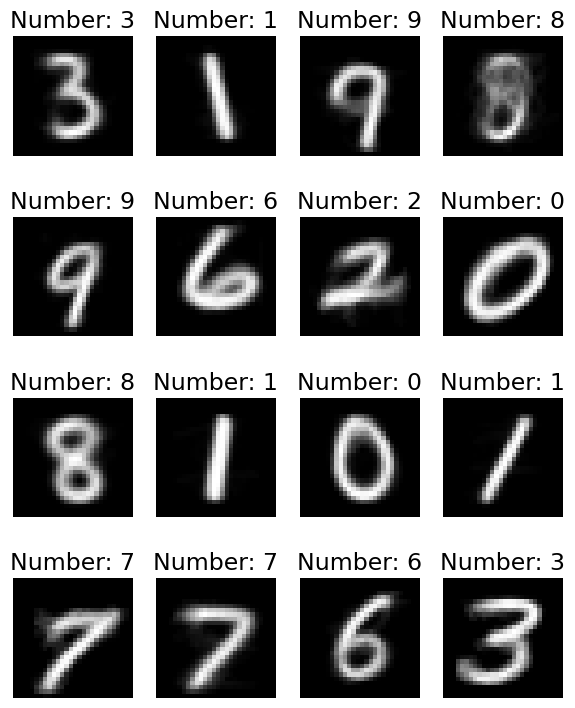

In [17]:
centroids = centroids.reshape(256, 28, 28)
centroids *= 255

import matplotlib.pyplot as plt

plt.gray()
plt.figure(figsize=(10, 9))
bottom = 0.35

for i in range(16):
    plt.subplots_adjust(bottom)
    plt.subplot(4, 4, i + 1)
    plt.title(f"Number: {reference_labels[i]}", fontsize=17)
    plt.imshow(centroids[i])
    plt.axis("off")